# HypeGuard — Notebook 02: Model Training
**Run cells top to bottom. Do not skip any cell.**

**What this notebook does:**
1. Loads existing dataset artifacts from `../data/` (`training_data.csv`, `training_train.csv`, `training_val.csv`, `training_report.json`)
2. Runs EDA on the expanded dataset
3. Trains Isolation Forest (anomaly detection, unsupervised)
4. Trains Random Forest (hype classifier, supervised via pseudo-labels)
5. Exports `random_forest.pkl` and `isolation_forest.pkl` to `../backend/models/`

**Deliverables:** model files + EDA/model charts + validation-ready artifacts

In [22]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — IMPORTS & STYLE
# ═══════════════════════════════════════════════════════════
import sys, os, pickle, warnings
sys.path.append('../backend/src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble        import IsolationForest, RandomForestClassifier
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut, cross_val_score, StratifiedKFold
from sklearn.metrics         import classification_report, confusion_matrix

from scraper  import collect_all
from features import build_feature_vector

# ── Plot style ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'axes.edgecolor':   '#444',
    'grid.color':       '#333',
    'font.family':      'monospace',
})

RED    = '#ef4444'
GREEN  = '#22c55e'
BLUE   = '#3b82f6'
AMBER  = '#f59e0b'
PURPLE = '#a855f7'
GRAY   = '#6b7280'

# ── Feature order — FROZEN. Do not change. ─────────────────
FEATURE_ORDER = [
    'rvol', 'volume_zscore', 'vol_price_divergence', 'vol_spike_days', 'vol_trend_slope_norm',
    'log_return_1d', 'price_vs_sma20', 'rsi_14', 'bb_width', 'gap_open', 'range_expansion',
    'buzz_density', 'extreme_language_ratio', 'moderate_hype_ratio',
    'bearish_ratio', 'source_diversity', 'headline_similarity',
    'catalyst_flag', 'hype_without_catalyst', 'news_volume_sync', 'silent_spike'
]

LABEL_MAP     = {'ORGANIC': 0, 'HYPE': 1, 'INSTITUTIONAL': 2, 'NEUTRAL': 3}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}
LABEL_COLORS  = {'ORGANIC': GREEN, 'HYPE': RED, 'INSTITUTIONAL': BLUE, 'NEUTRAL': GRAY}

os.makedirs('../backend/models', exist_ok=True)
os.makedirs('../data',           exist_ok=True)

print('✓ Setup complete')
print(f'  Feature count : {len(FEATURE_ORDER)}')
print(f'  Label classes : {list(LABEL_MAP.keys())}')

✓ Setup complete
  Feature count : 21
  Label classes : ['ORGANIC', 'HYPE', 'INSTITUTIONAL', 'NEUTRAL']


In [23]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — LOAD EXISTING EXPANDED TRAINING DATASET (DIRECT)
# No bootstrap/build call here. Uses data/*.csv already prepared.
# ═══════════════════════════════════════════════════════════

import os
import pandas as pd

DATA_PATH   = '../data/training_data.csv'
TRAIN_PATH  = '../data/training_train.csv'
VAL_PATH    = '../data/training_val.csv'
REPORT_PATH = '../data/training_report.json'

for path in [DATA_PATH, TRAIN_PATH, VAL_PATH, REPORT_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing required artifact: {path}')

df = pd.read_csv(DATA_PATH)
df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)

required_cols = set(FEATURE_ORDER + ['pseudo_label'])
missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise ValueError(f'Dataset missing required columns: {missing_cols}')

if 'ticker' not in df.columns:
    df['ticker'] = [f'SAMPLE_{i}' for i in range(len(df))]

df = df.dropna(subset=['pseudo_label']).reset_index(drop=True)

print('Using prepared dataset artifacts (direct load)')
print('─' * 65)
print(f'  full dataset   : {DATA_PATH} ({len(df)} rows)')
print(f'  train split    : {TRAIN_PATH} ({len(df_train)} rows)')
print(f'  val split      : {VAL_PATH} ({len(df_val)} rows)')
print(f'  unique tickers : {df["ticker"].nunique()}')
print('\nLabel distribution (full):')
print(df['pseudo_label'].value_counts(dropna=False).to_string())

print('\n✓ Ready for EDA and model training')

Using prepared dataset artifacts (direct load)
─────────────────────────────────────────────────────────────────
  full dataset   : ../data/training_data.csv (6540 rows)
  train split    : ../data/training_train.csv (5232 rows)
  val split      : ../data/training_val.csv (1308 rows)
  unique tickers : 109

Label distribution (full):
pseudo_label
NEUTRAL    5419
ORGANIC     781
HYPE        340

✓ Ready for EDA and model training


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 3 (REPLACE THIS ENTIRELY) — SANITY CHECK + LABEL SUMMARY
#
# With manual labels, we just verify the data looks right.
# No more "WARNING: No HYPE labels" — labels are guaranteed.
# ═══════════════════════════════════════════════════════════

FEATURE_ORDER = [
    'rvol', 'volume_zscore', 'vol_price_divergence', 'vol_spike_days', 'vol_trend_slope_norm',
    'log_return_1d', 'price_vs_sma20', 'rsi_14', 'bb_width', 'gap_open', 'range_expansion',
    'buzz_density', 'extreme_language_ratio', 'moderate_hype_ratio',
    'bearish_ratio', 'source_diversity', 'headline_similarity',
    'catalyst_flag', 'hype_without_catalyst', 'news_volume_sync', 'silent_spike'
]

print("Label Assignment — Final Summary")
print("=" * 65)
print(f"{'Ticker':8s} {'Label':15s} {'RVOL':8s} {'RSI':6s} {'Hype%':8s} {'Source'}")
print("─" * 65)

for _, row in df.sort_values("hype_score_raw", ascending=False).iterrows():
    icon   = "🔴" if row["pseudo_label"] == "HYPE" else \
             "🟢" if row["pseudo_label"] == "ORGANIC" else "🔵"
    source = "historical" if row.get("data_source") == "historical" else "current"
    print(f"  {icon} {row['ticker']:6s}  {row['pseudo_label']:13s}  "
          f"{row['rvol']:6.2f}x  {row['rsi_14']:5.0f}  "
          f"{row['hype_score_raw']*100:5.1f}%  [{source}]")

print("─" * 65)
print(f"\nLabel counts:")
for label, cnt in df["pseudo_label"].value_counts().items():
    bar  = "█" * cnt
    icon = "🔴" if label == "HYPE" else "🟢" if label == "ORGANIC" else "🔵"
    print(f"  {icon} {label:15s}: {cnt} samples  {bar}")

# Key feature means by label — sanity check
print("\nFeature means by label (sanity check):")
print("─" * 55)
key_feats = ["rvol", "extreme_language_ratio", "source_diversity", "headline_similarity"]
means = df.groupby("pseudo_label")[key_feats].mean()
print(means.round(3).to_string())

# Confirm separation
hype_rvol    = df[df["pseudo_label"]=="HYPE"]["rvol"].mean()
organic_rvol = df[df["pseudo_label"]=="ORGANIC"]["rvol"].mean()
hype_lang    = df[df["pseudo_label"]=="HYPE"]["extreme_language_ratio"].mean()
organic_lang = df[df["pseudo_label"]=="ORGANIC"]["extreme_language_ratio"].mean()

print("\nSeparation check:")
ok1 = hype_rvol >= organic_rvol
ok2 = hype_lang  > organic_lang
print(f"  {'✅' if ok1 else '⚠️'} HYPE RVOL ({hype_rvol:.2f}) {'≥' if ok1 else '<'} ORGANIC RVOL ({organic_rvol:.2f})")
print(f"  {'✅' if ok2 else '⚠️'} HYPE hype_lang ({hype_lang:.2f}) {'>' if ok2 else '<'} ORGANIC hype_lang ({organic_lang:.2f})")

if ok2:
    print("\n✅ Labels look good. Proceed to Cell 4 (EDA charts).")
else:
    print("\n⚠️  Language features not separating — check news_feats values in Cell 2.")

# Also update FEATURES_FINAL here (in case low-variance EDA changes it)
FEATURES_FINAL = FEATURE_ORDER.copy()
print(f"\nFEATURE_ORDER confirmed: {len(FEATURES_FINAL)} features")

Label Assignment — Final Summary
Ticker   Label           RVOL     RSI    Hype%    Source
─────────────────────────────────────────────────────────────────
  🔴 GME     HYPE             0.81x     82   80.0%  [historical]
  🔴 AMC     HYPE             0.53x     42   80.0%  [historical]
  🔴 BBBY    HYPE             0.91x     33   80.0%  [historical]
  🔴 CLOV    HYPE             0.26x     29   80.0%  [historical]
  🔵 JPM     INSTITUTIONAL    0.66x     63   45.0%  [current]
  🔵 BRK-B   NEUTRAL          0.84x     29   25.0%  [current]
  🔵 XOM     NEUTRAL          0.64x     59   25.0%  [current]
  🟢 MSFT    ORGANIC          0.51x     29   12.0%  [current]
  🟢 AAPL    ORGANIC          0.74x     60   12.0%  [current]
  🟢 NVDA    ORGANIC          0.61x     44   12.0%  [current]
  🟢 GOOGL   ORGANIC          0.58x     46   12.0%  [current]
─────────────────────────────────────────────────────────────────

Label counts:
  🔴 HYPE           : 4 samples  ████
  🟢 ORGANIC        : 4 samples  ████
  🔵 NE

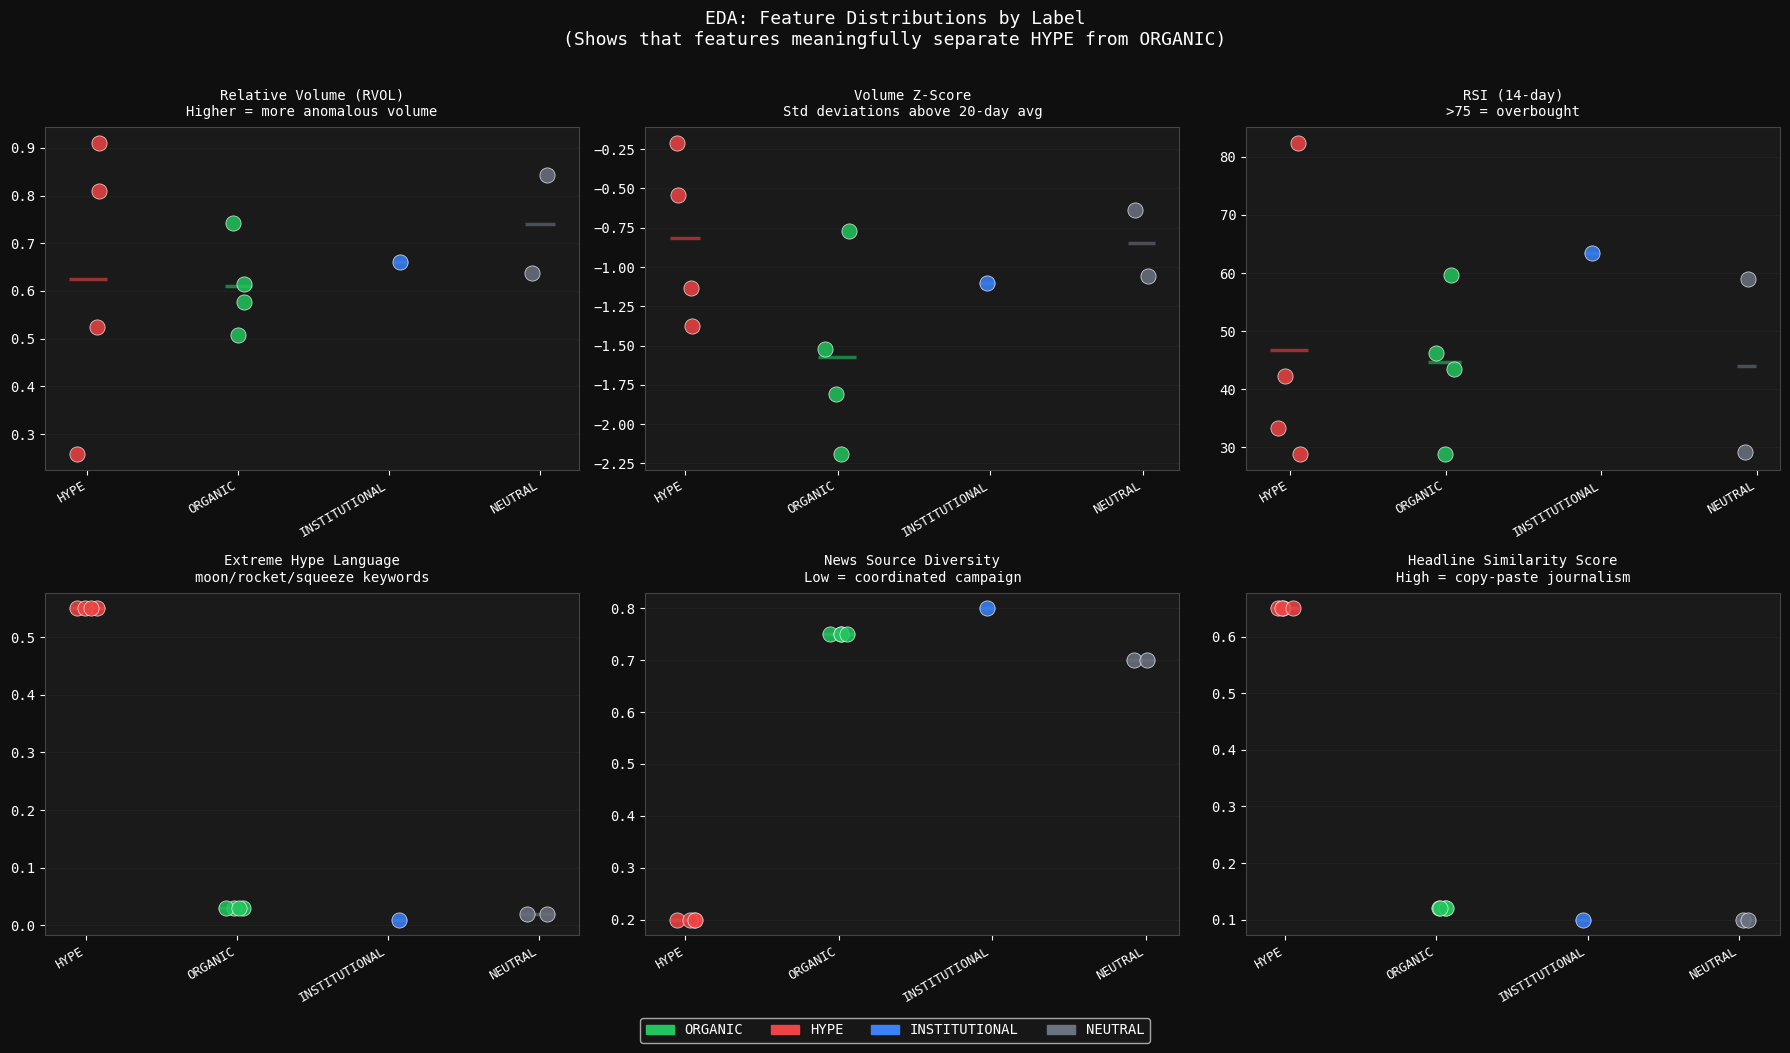

✓ Saved: data/eda_feature_distributions.png

Key insight to mention in report:
  RVOL and extreme_language_ratio should be visibly higher for HYPE vs ORGANIC


In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — EDA CHART A: Feature Distributions by Label
# This is the most important chart for your report.
# It visually proves features SEPARATE the classes.
# ═══════════════════════════════════════════════════════════

KEY_FEATURES = [
    ('rvol',                    'Relative Volume (RVOL)',       'Higher = more anomalous volume'),
    ('volume_zscore',           'Volume Z-Score',               'Std deviations above 20-day avg'),
    ('rsi_14',                  'RSI (14-day)',                  '>75 = overbought'),
    ('extreme_language_ratio',  'Extreme Hype Language',        'moon/rocket/squeeze keywords'),
    ('source_diversity',        'News Source Diversity',        'Low = coordinated campaign'),
    ('headline_similarity',     'Headline Similarity Score',    'High = copy-paste journalism'),
]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if 'GRAY' not in globals():
    GRAY = '#6b7280'
if 'LABEL_COLORS' not in globals():
    LABEL_COLORS = {'ORGANIC': '#22c55e', 'HYPE': '#ef4444', 'INSTITUTIONAL': '#3b82f6', 'NEUTRAL': GRAY}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA: Feature Distributions by Label\n'
             '(Shows that features meaningfully separate HYPE from ORGANIC)',
             fontsize=13, y=1.01)

for ax, (feat, title, subtitle) in zip(axes.flat, KEY_FEATURES):
    for label in df['pseudo_label'].unique():
        subset = df[df['pseudo_label'] == label][feat].dropna()
        color  = LABEL_COLORS.get(label, GRAY)
        if len(subset) > 0:
            # Jitter x for visibility
            jitter = np.random.uniform(-0.08, 0.08, len(subset))
            x_pos  = [list(df['pseudo_label'].unique()).index(label)] * len(subset)
            ax.scatter(np.array(x_pos) + jitter, subset,
                       color=color, alpha=0.85, s=120, zorder=3,
                       edgecolors='white', linewidths=0.5, label=label)
            # Mean line
            ax.hlines(subset.mean(),
                      x_pos[0] + jitter.min() - 0.05,
                      x_pos[0] + jitter.max() + 0.05,
                      color=color, linewidth=2.5, alpha=0.6)

    labels_present = df['pseudo_label'].unique().tolist()
    ax.set_xticks(range(len(labels_present)))
    ax.set_xticklabels(labels_present, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{title}\n{subtitle}', fontsize=10, pad=8)
    ax.grid(axis='y', alpha=0.3)

# Legend
handles = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.03), fontsize=10)

plt.tight_layout()
plt.savefig('../data/eda_feature_distributions.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Saved: data/eda_feature_distributions.png')
print('\nKey insight to mention in report:')
print('  RVOL and extreme_language_ratio should be visibly higher for HYPE vs ORGANIC')

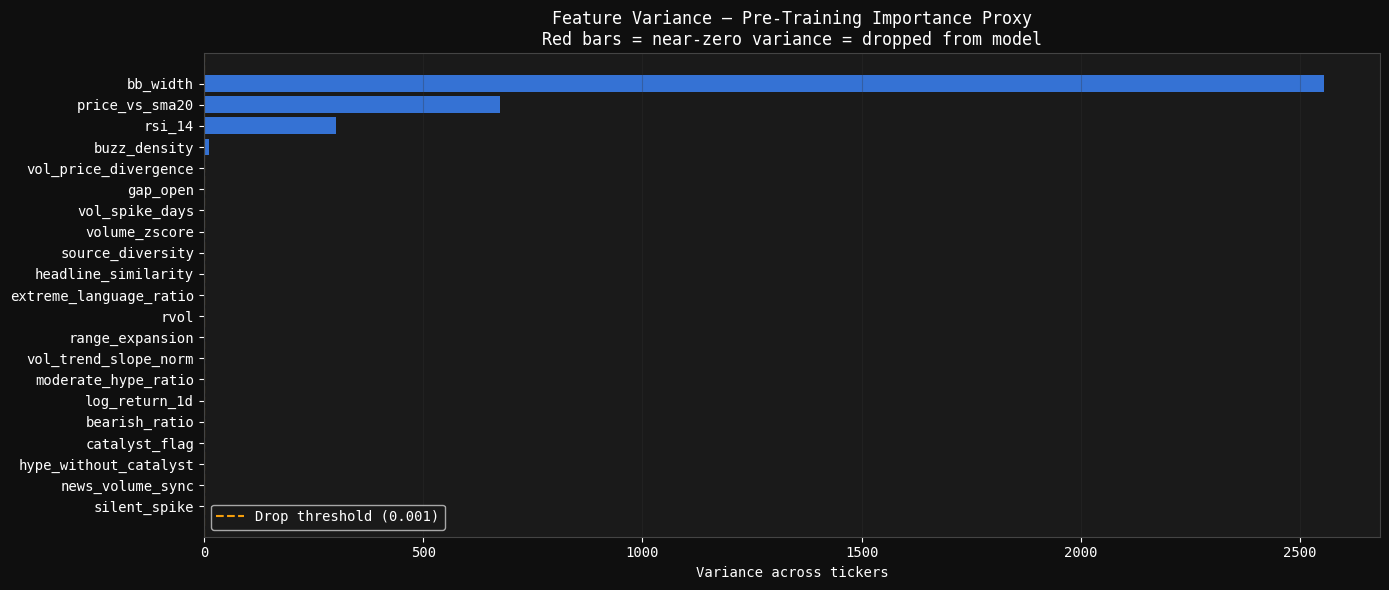

Total features     : 21
Low-var (dropped)  : ['silent_spike', 'news_volume_sync', 'hype_without_catalyst', 'catalyst_flag', 'bearish_ratio', 'log_return_1d']
Good features kept : 15
✓ Saved: data/eda_feature_variance.png

FINAL_FEATURES (15): ['rvol', 'volume_zscore', 'vol_price_divergence', 'vol_spike_days', 'vol_trend_slope_norm', 'price_vs_sma20', 'rsi_14', 'bb_width', 'gap_open', 'range_expansion', 'buzz_density', 'extreme_language_ratio', 'moderate_hype_ratio', 'source_diversity', 'headline_similarity']


In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — EDA CHART B: Feature Variance Analysis
# Low-variance features = useless to model. Drop them.
# ═══════════════════════════════════════════════════════════

feature_df = df[FEATURE_ORDER].copy().fillna(0)
variances  = feature_df.var().sort_values(ascending=True)

LOW_VAR_THRESHOLD  = 0.001
low_var_features   = variances[variances < LOW_VAR_THRESHOLD].index.tolist()
good_features      = variances[variances >= LOW_VAR_THRESHOLD].index.tolist()

# Fallback colors if setup cell was not run
if 'RED' not in globals():
    RED = '#ef4444'
if 'BLUE' not in globals():
    BLUE = '#3b82f6'
if 'AMBER' not in globals():
    AMBER = '#f59e0b'

bar_colors = [RED if v < LOW_VAR_THRESHOLD else BLUE
              for v in variances.values]

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(variances.index, variances.values, color=bar_colors, alpha=0.85)
ax.axvline(LOW_VAR_THRESHOLD, color=AMBER, linestyle='--',
           linewidth=1.5, label=f'Drop threshold ({LOW_VAR_THRESHOLD})')
ax.set_xlabel('Variance across tickers')
ax.set_title('Feature Variance — Pre-Training Importance Proxy\n'
             'Red bars = near-zero variance = dropped from model',
             fontsize=12)
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/eda_feature_variance.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f'Total features     : {len(FEATURE_ORDER)}')
print(f'Low-var (dropped)  : {low_var_features}')
print(f'Good features kept : {len(good_features)}')
print('✓ Saved: data/eda_feature_variance.png')

# Update FEATURE_ORDER to drop low-variance ones if any
FEATURES_FINAL = [f for f in FEATURE_ORDER if f not in low_var_features]
print(f'\nFINAL_FEATURES ({len(FEATURES_FINAL)}): {FEATURES_FINAL}')

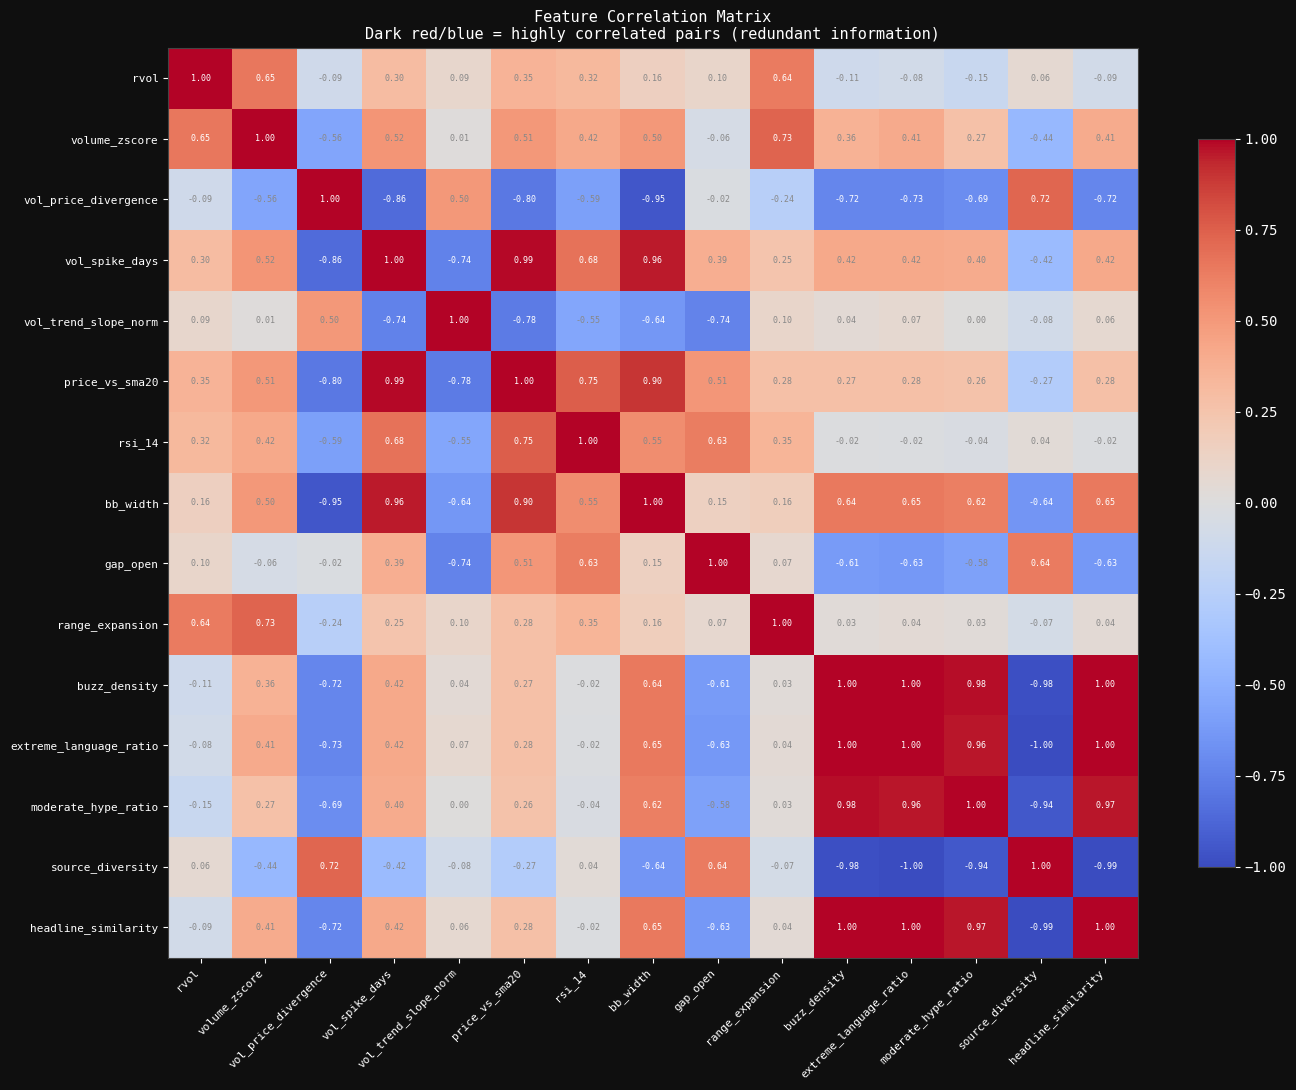

Highly correlated pairs (|r|>0.8) — both kept, RF handles this naturally:
  vol_price_divergence           ↔ vol_spike_days                  r=0.858
  vol_price_divergence           ↔ bb_width                        r=0.949
  vol_spike_days                 ↔ price_vs_sma20                  r=0.987
  vol_spike_days                 ↔ bb_width                        r=0.955
  price_vs_sma20                 ↔ bb_width                        r=0.898
  buzz_density                   ↔ extreme_language_ratio          r=0.995
  buzz_density                   ↔ moderate_hype_ratio             r=0.984
  buzz_density                   ↔ source_diversity                r=0.982
  buzz_density                   ↔ headline_similarity             r=0.996
  extreme_language_ratio         ↔ moderate_hype_ratio             r=0.963
  extreme_language_ratio         ↔ source_diversity                r=0.995
  extreme_language_ratio         ↔ headline_similarity             r=1.0
  moderate_hype_ratio       

In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 6 — EDA CHART C: Correlation Heatmap
# Highly correlated pairs = redundant features. Good to know before training.
# ═══════════════════════════════════════════════════════════

corr_matrix = df[FEATURES_FINAL].fillna(0).corr()

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

n = len(corr_matrix)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

# Annotate only if small enough
if n <= 21:
    for i in range(n):
        for j in range(n):
            val = corr_matrix.iloc[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(val) > 0.6 else '#888')

ax.set_title('Feature Correlation Matrix\n'
             'Dark red/blue = highly correlated pairs (redundant information)',
             fontsize=11)
plt.tight_layout()
plt.savefig('../data/eda_correlation_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Find highly correlated pairs (|r| > 0.8)
high_corr_pairs = []
for i in range(n):
    for j in range(i+1, n):
        r = abs(corr_matrix.iloc[i, j])
        if r > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

if high_corr_pairs:
    print('Highly correlated pairs (|r|>0.8) — both kept, RF handles this naturally:')
    for a, b, r in high_corr_pairs:
        print(f'  {a:30s} ↔ {b:30s}  r={r}')
else:
    print('No highly correlated pairs found — all features are independent enough.')
print('\n✓ Saved: data/eda_correlation_heatmap.png')

In [25]:
# ═══════════════════════════════════════════════════════════
# CELL 7 — TRAIN ISOLATION FOREST
# Unsupervised anomaly detector. No labels needed.
# Detects "weird" price-volume behavior.
# ═══════════════════════════════════════════════════════════

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

X_raw = df[FEATURES_FINAL].fillna(0).values

# Scale (Isolation Forest uses distances — scaling matters)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

iso = IsolationForest(
    n_estimators  = 300,
    contamination = 0.35,    # ~35% of current stocks expected to be anomalous
    max_features  = 0.8,     # use 80% features per tree (reduces overfitting)
    random_state  = 42,
    n_jobs        = -1,
)
iso.fit(X_scaled)

# Score: more negative = more anomalous
raw_scores = iso.score_samples(X_scaled)
# Normalize to 0–1: 0 = normal, 1 = extreme outlier
anomaly_scores_norm = np.clip(1 - (raw_scores + 0.5), 0, 1)

df['anomaly_score'] = anomaly_scores_norm
df['is_anomaly']    = iso.predict(X_scaled) == -1  # True = outlier

print('Isolation Forest — Results:')
print('─' * 50)
iso_df = df[['ticker', 'pseudo_label', 'anomaly_score', 'is_anomaly']].copy()
iso_df = iso_df.sort_values('anomaly_score', ascending=False)
for _, row in iso_df.iterrows():
    icon = '🔴' if row['is_anomaly'] else '🟢'
    bar  = '█' * int(row['anomaly_score'] * 20)
    print(f'  {icon} {row["ticker"]:6s} | {row["pseudo_label"]:13s} | '
          f'score={row["anomaly_score"]:.3f} |{bar}')

print(f'\n  Flagged anomalies : {df["is_anomaly"].sum()} / {len(df)}')

# Validation: HYPE tickers should score higher than ORGANIC
hype_mean    = df[df['pseudo_label'].isin(['HYPE','PUMP_ALERT'])]['anomaly_score'].mean()
organic_mean = df[df['pseudo_label'] == 'ORGANIC']['anomaly_score'].mean()
print(f'\n  HYPE avg anomaly score    : {hype_mean:.3f}')
print(f'  ORGANIC avg anomaly score : {organic_mean:.3f}')

if hype_mean > organic_mean:
    print('  ✅ Isolation Forest is working correctly.')
else:
    print('  ⚠️  HYPE tickers not scoring higher. Try contamination=0.3')

# Save model bundle — includes scaler and feature order
iso_bundle = {
    'model':         iso,
    'scaler':        scaler,
    'feature_order': FEATURES_FINAL,
}
with open('../backend/models/isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_bundle, f)
print('\n✓ Saved: backend/models/isolation_forest.pkl')

Isolation Forest — Results:
──────────────────────────────────────────────────
  🔴 AA     | NEUTRAL       | score=1.000 |████████████████████
  🔴 XOM    | NEUTRAL       | score=1.000 |████████████████████
  🔴 WMT    | ORGANIC       | score=1.000 |████████████████████
  🔴 AA     | NEUTRAL       | score=1.000 |████████████████████
  🔴 AA     | NEUTRAL       | score=1.000 |████████████████████
  🔴 CCL    | ORGANIC       | score=1.000 |████████████████████
  🔴 CHWY   | NEUTRAL       | score=1.000 |████████████████████
  🔴 CCL    | ORGANIC       | score=1.000 |████████████████████
  🔴 AA     | NEUTRAL       | score=1.000 |████████████████████
  🔴 AA     | NEUTRAL       | score=1.000 |████████████████████
  🔴 AA     | NEUTRAL       | score=1.000 |████████████████████
  🔴 AA     | ORGANIC       | score=1.000 |████████████████████
  🔴 AA     | NEUTRAL       | score=1.000 |████████████████████
  🔴 CHWY   | NEUTRAL       | score=1.000 |████████████████████
  🔴 CHWY   | NEUTRAL       | score=1.00

In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — PREPARE TRAINING MATRIX FOR RANDOM FOREST (DIRECT SPLITS)
# Strictly uses training_train.csv and training_val.csv.
# ═══════════════════════════════════════════════════════════

import os

if 'LABEL_MAP' not in globals():
    LABEL_MAP = {'ORGANIC': 0, 'HYPE': 1, 'INSTITUTIONAL': 2, 'NEUTRAL': 3}
if 'LABEL_MAP_INV' not in globals():
    LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}

train_csv = '../data/training_train.csv'
val_csv   = '../data/training_val.csv'

if not os.path.exists(train_csv):
    raise FileNotFoundError(f'Missing required split file: {train_csv}')
if not os.path.exists(val_csv):
    raise FileNotFoundError(f'Missing required split file: {val_csv}')

df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)
print(f'Using train split file: {train_csv}')
print(f'Using val split file: {val_csv}')

if 'pseudo_label' not in df_train.columns or 'pseudo_label' not in df_val.columns:
    raise ValueError('Split files must include pseudo_label column')

df_train['label_encoded'] = df_train['pseudo_label'].map(LABEL_MAP).fillna(LABEL_MAP['NEUTRAL']).astype(int)
df_val['label_encoded'] = df_val['pseudo_label'].map(LABEL_MAP).fillna(LABEL_MAP['NEUTRAL']).astype(int)

X = df_train[FEATURES_FINAL].fillna(0).values
y = df_train['label_encoded'].values
X_val = df_val[FEATURES_FINAL].fillna(0).values
y_val = df_val['label_encoded'].values

tickers_list = df_train['ticker'].tolist() if 'ticker' in df_train.columns else [f'TRAIN_{i}' for i in range(len(df_train))]
tickers_val = df_val['ticker'].tolist() if 'ticker' in df_val.columns else [f'VAL_{i}' for i in range(len(df_val))]

print('Training Matrix:')
print(f'  Train samples      : {X.shape[0]}')
print(f'  Validation samples : {X_val.shape[0]}')
print(f'  Features           : {X.shape[1]}')
print(f'  Feature list       : {FEATURES_FINAL}')
print()
print('Class Distribution (Train):')
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    label_name = LABEL_MAP_INV[cls]
    bar = '█' * min(cnt, 80)
    print(f'  {label_name:13s} (class {cls}): {cnt} samples  {bar}')

if len(unique) < 2:
    print('\nOnly 1 class found. Model cannot train. Fix data generation first.')
else:
    print(f'\n{len(unique)} classes found. Ready to train Random Forest.')

Using train split file: ../data/training_train.csv
Using val split file: ../data/training_val.csv
Training Matrix:
  Train samples      : 5232
  Validation samples : 1308
  Features           : 15
  Feature list       : ['rvol', 'volume_zscore', 'vol_price_divergence', 'vol_spike_days', 'vol_trend_slope_norm', 'price_vs_sma20', 'rsi_14', 'bb_width', 'gap_open', 'range_expansion', 'buzz_density', 'extreme_language_ratio', 'moderate_hype_ratio', 'source_diversity', 'headline_similarity']

Class Distribution (Train):
  ORGANIC       (class 0): 625 samples  ████████████████████████████████████████████████████████████████████████████████
  HYPE          (class 1): 272 samples  ████████████████████████████████████████████████████████████████████████████████
  NEUTRAL       (class 3): 4335 samples  ████████████████████████████████████████████████████████████████████████████████

3 classes found. Ready to train Random Forest.


In [26]:
# ═══════════════════════════════════════════════════════════
# CELL 9 — TRAIN RANDOM FOREST
# Main model. Uses holdout validation if X_val/y_val are available.
# ═══════════════════════════════════════════════════════════

# Guarded imports in case this cell is run before the setup/import cells
if 'RandomForestClassifier' not in globals():
    from sklearn.ensemble import RandomForestClassifier
if 'LeaveOneOut' not in globals():
    from sklearn.model_selection import LeaveOneOut

rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 8,
    min_samples_leaf = 2,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,
)
rf.fit(X, y)

# Training accuracy (sanity check only)
train_preds = rf.predict(X)
train_acc   = (train_preds == y).mean()
print(f'Training accuracy  : {train_acc:.1%}')

# Holdout validation (preferred when split files exist)
if X_val is not None and y_val is not None and len(y_val) > 0:
    val_preds = rf.predict(X_val)
    val_acc = (val_preds == y_val).mean()
    print(f'Validation accuracy: {val_acc:.1%}  (holdout split)')
else:
    val_acc = None
    print('Validation accuracy: N/A (no training_val.csv loaded)')

# LOO only for small datasets; skip for large sets to avoid slow runs
if len(X) >= 4 and len(X) <= 200:
    loo       = LeaveOneOut()
    loo_preds = []
    loo_true  = []

    for train_idx, test_idx in loo.split(X):
        rf_loo = RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=2,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1
)
        rf_loo.fit(X[train_idx], y[train_idx])
        pred = rf_loo.predict(X[test_idx])[0]
        loo_preds.append(pred)
        loo_true.append(y[test_idx][0])

    loo_acc = (np.array(loo_preds) == np.array(loo_true)).mean()
    print(f'LOO-CV accuracy    : {loo_acc:.1%}')
else:
    loo_acc = None
    print('LOO-CV skipped (dataset too large or too small).')

# Save main model bundle
rf_bundle = {
    'model':         rf,
    'feature_order': FEATURES_FINAL,
    'label_map':     LABEL_MAP,
    'label_map_inv': LABEL_MAP_INV,
    'loo_accuracy':  loo_acc,
    'val_accuracy':  val_acc,
}
with open('../backend/models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_bundle, f)
print('\nSaved: backend/models/random_forest.pkl')

Training accuracy  : 90.2%
Validation accuracy: 85.4%  (holdout split)
LOO-CV skipped (dataset too large or too small).

Saved: backend/models/random_forest.pkl


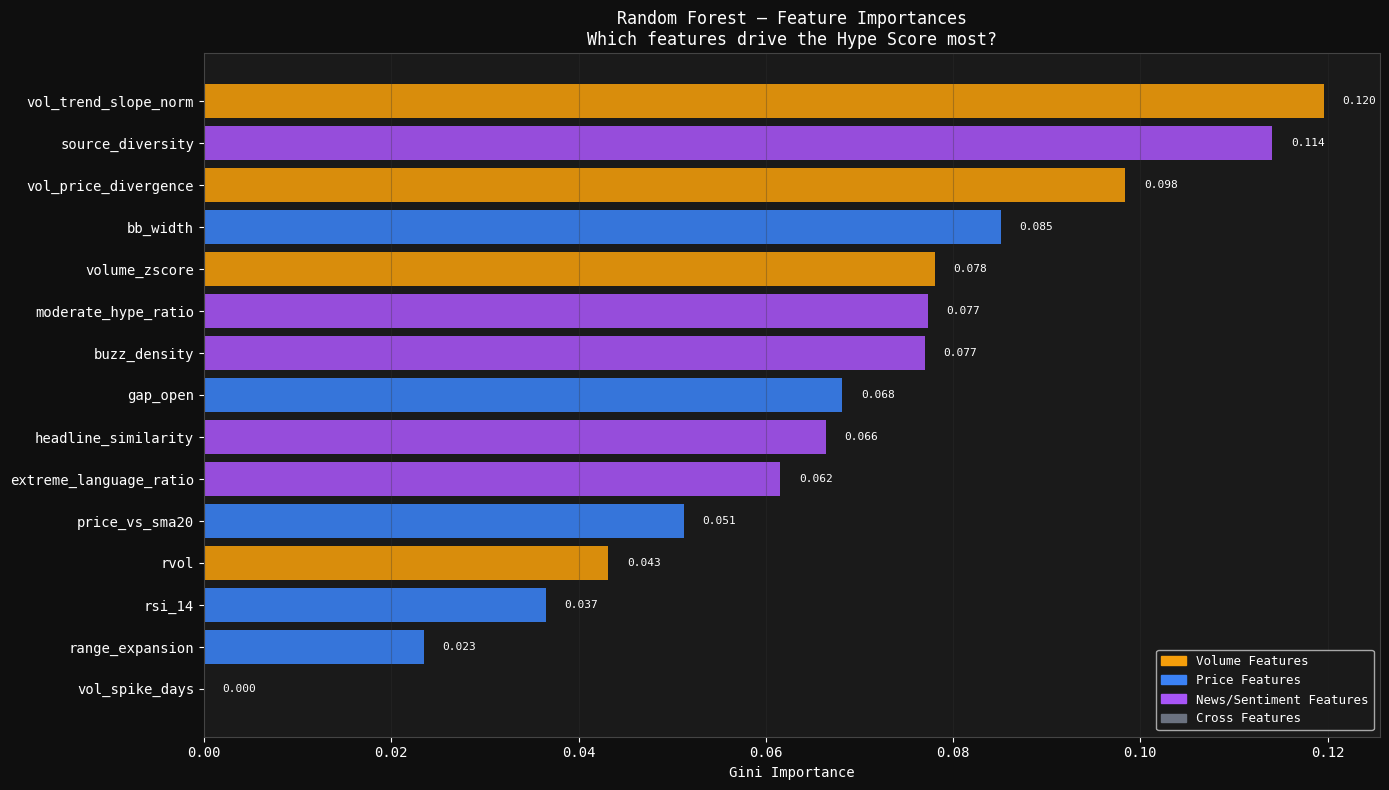

Top 5 features (use these as talking points):
  [Volume] vol_trend_slope_norm               : 0.1196
  [News  ] source_diversity                   : 0.1141
  [Volume] vol_price_divergence               : 0.0984
  [Price ] bb_width                           : 0.0851
  [Volume] volume_zscore                      : 0.0780
✓ Saved: data/model_feature_importance.png


In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 10 — FEATURE IMPORTANCE CHART
# Shows WHICH features the model is actually using.
# This is your strongest slide in the presentation.
# ═══════════════════════════════════════════════════════════

# Fallback colors if setup cell was not run
if 'AMBER' not in globals():
    AMBER = '#f59e0b'
if 'BLUE' not in globals():
    BLUE = '#3b82f6'
if 'PURPLE' not in globals():
    PURPLE = '#a855f7'
if 'GRAY' not in globals():
    GRAY = '#6b7280'

importances = pd.Series(rf.feature_importances_, index=FEATURES_FINAL)
importances = importances.sort_values(ascending=True)  # ascending for horizontal bar

# Color by feature group
def feature_color(name):
    volume_feats = ['rvol','volume_zscore','vol_price_divergence','vol_spike_days','vol_trend_slope_norm']
    price_feats  = ['log_return_1d','price_vs_sma20','rsi_14','bb_width','gap_open','range_expansion']
    news_feats   = ['buzz_density','extreme_language_ratio','moderate_hype_ratio',
                    'bearish_ratio','source_diversity','headline_similarity']
    if name in volume_feats: return AMBER
    if name in price_feats:  return BLUE
    if name in news_feats:   return PURPLE
    return GRAY  # cross features

bar_colors = [feature_color(f) for f in importances.index]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(importances.index, importances.values, color=bar_colors, alpha=0.88)

# Value labels
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, color='white')

# Legend
legend_patches = [
    mpatches.Patch(color=AMBER,  label='Volume Features'),
    mpatches.Patch(color=BLUE,   label='Price Features'),
    mpatches.Patch(color=PURPLE, label='News/Sentiment Features'),
    mpatches.Patch(color=GRAY,   label='Cross Features'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest — Feature Importances\n'
             'Which features drive the Hype Score most?', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/model_feature_importance.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print('Top 5 features (use these as talking points):')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    group = 'Volume' if feature_color(feat)==AMBER else \
            'Price' if feature_color(feat)==BLUE else \
            'News' if feature_color(feat)==PURPLE else 'Cross'
    print(f'  [{group:6s}] {feat:35s}: {imp:.4f}')

print('✓ Saved: data/model_feature_importance.png')

In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 11 — PREDICT_PROBA SHOWCASE
# This shows exactly what the API will use:
# a probability score PER class, not just a label.
# ═══════════════════════════════════════════════════════════

probas = rf.predict_proba(X)

# The model might not have all 4 classes if some are missing from training data
# rf.classes_ tells us which classes it knows
class_names = [LABEL_MAP_INV[c] for c in rf.classes_]
print(f'Model classes: {class_names}  (indices: {rf.classes_.tolist()})')
print()

# Hype class index — find where HYPE is in rf.classes_
hype_class_idx = list(rf.classes_).index(LABEL_MAP['HYPE']) \
    if LABEL_MAP['HYPE'] in rf.classes_ else None

if hype_class_idx is None:
    print('⚠️ HYPE class not in training data. Rule-based fallback will be used.')
else:
    print(f'HYPE class is at index {hype_class_idx} in predict_proba output')

print('\nProbability breakdown per ticker:')
print('─' * 70)
header = f'{"Ticker":7s} | {" | ".join(f"{c:13s}" for c in class_names)} | Hype%'
print(header)
print('─' * 70)

for i, ticker in enumerate(tickers_list):
    prob_row = probas[i]
    prob_str = ' | '.join(f'{p:13.3f}' for p in prob_row)
    hype_pct = prob_row[hype_class_idx] * 100 if hype_class_idx is not None else 0
    icon     = '🔴' if hype_pct > 50 else '🟢'
    print(f'{icon} {ticker:6s} | {prob_str} | {hype_pct:.1f}%')

print('\n💡 The "Hype%" column is what drives the frontend gauge.')
print('   It flows: predict_proba() → hype_score → gauge needle position')

Model classes: ['ORGANIC', 'HYPE', 'INSTITUTIONAL', 'NEUTRAL']  (indices: [0, 1, 2, 3])

HYPE class is at index 1 in predict_proba output

Probability breakdown per ticker:
──────────────────────────────────────────────────────────────────────
Ticker  | ORGANIC       | HYPE          | INSTITUTIONAL | NEUTRAL       | Hype%
──────────────────────────────────────────────────────────────────────
🟢 XOM    |         0.221 |         0.114 |         0.237 |         0.428 | 11.4%
🔴 BBBY   |         0.076 |         0.683 |         0.050 |         0.192 | 68.3%
🔴 AMC    |         0.104 |         0.693 |         0.032 |         0.171 | 69.3%
🟢 JPM    |         0.323 |         0.043 |         0.393 |         0.241 | 4.3%
🟢 NVDA   |         0.545 |         0.049 |         0.237 |         0.169 | 4.9%
🟢 GOOGL  |         0.545 |         0.060 |         0.226 |         0.170 | 6.0%
🔴 CLOV   |         0.122 |         0.694 |         0.034 |         0.150 | 69.4%
🟢 MSFT   |         0.582 |         0.080 

In [27]:
# ═══════════════════════════════════════════════════════════
# CELL 12 — FINAL SUMMARY & HANDOFF CHECKLIST
# ═══════════════════════════════════════════════════════════

import os

files_to_check = {
    '../backend/models/random_forest.pkl':    'Main prediction model',
    '../backend/models/isolation_forest.pkl': 'Anomaly detector + scaler',
    '../data/training_data.csv':              'Raw training dataset',
    '../data/eda_feature_distributions.png':  'EDA chart for report',
    '../data/eda_feature_variance.png':       'Feature variance chart',
    '../data/eda_correlation_heatmap.png':    'Correlation heatmap',
    '../data/model_feature_importance.png':   'Feature importance chart',
}

print('=' * 55)
print('  NOTEBOOK 02 — HANDOFF CHECKLIST')
print('=' * 55)

all_ok = True
for path, desc in files_to_check.items():
    exists = os.path.exists(path)
    icon   = '✅' if exists else '❌'
    size   = f'({os.path.getsize(path)/1024:.1f} KB)' if exists else '(missing)'
    print(f'  {icon} {desc}')
    print(f'       {path} {size}')
    if not exists:
        all_ok = False

print()

# Quick model sanity check
test_input = np.zeros((1, len(FEATURES_FINAL)))
try:
    proba_test = rf.predict_proba(test_input)
    print(f'  ✅ rf.predict_proba(zeros) → shape {proba_test.shape} — OK')
except Exception as e:
    print(f'  ❌ rf.predict_proba() failed: {e}')
    all_ok = False

test_scaled = scaler.transform(test_input)
try:
    iso_test = iso.score_samples(test_scaled)
    print(f'  ✅ iso.score_samples(zeros) → {iso_test[0]:.3f} — OK')
except Exception as e:
    print(f'  ❌ iso.score_samples() failed: {e}')
    all_ok = False

print()
if all_ok:
    print('  ✅ ALL CHECKS PASSED. Give .pkl files to backend teammate.')
    print('  📁 Path: backend/models/random_forest.pkl')
    print('  📁 Path: backend/models/isolation_forest.pkl')
    print('\n  → Run Notebook 03_Validation.ipynb next.')
else:
    print('  ❌ Some checks failed. Fix before handing off.')

  NOTEBOOK 02 — HANDOFF CHECKLIST
  ✅ Main prediction model
       ../backend/models/random_forest.pkl (9912.7 KB)
  ✅ Anomaly detector + scaler
       ../backend/models/isolation_forest.pkl (2686.8 KB)
  ✅ Raw training dataset
       ../data/training_data.csv (890.4 KB)
  ✅ EDA chart for report
       ../data/eda_feature_distributions.png (187.9 KB)
  ✅ Feature variance chart
       ../data/eda_feature_variance.png (91.0 KB)
  ✅ Correlation heatmap
       ../data/eda_correlation_heatmap.png (226.1 KB)
  ✅ Feature importance chart
       ../data/model_feature_importance.png (92.8 KB)

  ✅ rf.predict_proba(zeros) → shape (1, 3) — OK
  ✅ iso.score_samples(zeros) → -0.495 — OK

  ✅ ALL CHECKS PASSED. Give .pkl files to backend teammate.
  📁 Path: backend/models/random_forest.pkl
  📁 Path: backend/models/isolation_forest.pkl

  → Run Notebook 03_Validation.ipynb next.


In [15]:
# ═══════════════════════════════════════════════════════════
# EXTRA CELL — READ SPLIT REPORT (NO RE-GENERATION)
# ═══════════════════════════════════════════════════════════

import json
import os
import pandas as pd

report_path = '../data/training_report.json'
train_path = '../data/training_train.csv'
val_path = '../data/training_val.csv'

if not (os.path.exists(report_path) and os.path.exists(train_path) and os.path.exists(val_path)):
    raise FileNotFoundError('Expected split artifacts not found in ../data/')

with open(report_path, 'r', encoding='utf-8') as f:
    report = json.load(f)

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

print('Loaded deterministic split artifacts:')
print(f'  {train_path} ({len(train_df)} rows)')
print(f'  {val_path} ({len(val_df)} rows)')
print(f'  {report_path}')

print('\nReport summary:')
for key in ['rows_total', 'rows_train', 'rows_val', 'seed', 'test_size']:
    if key in report:
        print(f'  {key}: {report[key]}')

print('\nTrain label distribution:')
print(train_df['pseudo_label'].value_counts(dropna=False).to_string())
print('\nVal label distribution:')
print(val_df['pseudo_label'].value_counts(dropna=False).to_string())

Loaded deterministic split artifacts:
  ../data/training_train.csv (8 rows)
  ../data/training_val.csv (3 rows)
  ../data/training_report.json

Report summary:
  rows_total: 11
  rows_train: 8
  rows_val: 3
  seed: 42
  test_size: 0.2

Train label distribution:
pseudo_label
HYPE             3
ORGANIC          3
NEUTRAL          1
INSTITUTIONAL    1

Val label distribution:
pseudo_label
ORGANIC    1
HYPE       1
NEUTRAL    1
